##Importation des données

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [ ]:
!pip install kagglehub pandas numpy matplotlib lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 8.7 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=e7931a3762fa7534eb89abe48ae7e5bfc5457c8aeb8b15b3bda2b3044ed1cd2b
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma


In [ ]:
import os

print(os.listdir(path))

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [ ]:
import pandas as pd

file_path = os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv")

df = pd.read_csv(file_path)

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
df.shape

(7043, 21)

In [ ]:
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

In [ ]:
# --- Configuration globale des graphiques ---
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.dpi': 120,
})
sns.set_theme(style='whitegrid', palette='Set2')

##Compréhension des données

In [ ]:
# Valeurs manquantes — nombre et pourcentage
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Manquants': missing, '% Manquants': missing_pct})
print(missing_df[missing_df['Manquants'] > 0])
print('\n→ Certaines valeurs manquantes peuvent être masquées sous forme de chaînes vides.')

Empty DataFrame
Columns: [Manquants, % Manquants]
Index: []

→ Certaines valeurs manquantes peuvent être masquées sous forme de chaînes vides.


In [ ]:
# Statistiques descriptives des variables numériques
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
# Séparation variables numériques / catégorielles
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f'Variables numériques ({len(num_cols)}) : {num_cols}')
print(f'Variables catégorielles ({len(cat_cols)}) : {cat_cols}')

Variables numériques (3) : ['SeniorCitizen', 'tenure', 'MonthlyCharges']
Variables catégorielles (18) : ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [ ]:
# Modalités des variables catégorielles
# Important : on vérifie les valeurs uniques avant toute manipulation
for col in cat_cols:
    vals = df[col].value_counts()
    print(f'\n--- {col} ({len(vals)} modalités) ---')
    print(vals.to_string())

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
4200.25     1
939.7       1
6333.8      1
2967.35     1
7320.9      1
6218.45     1
242.05      1
2548.55     1
487.95      1
1222.25     1
93.4        1
5974.3      1
1327.4      1
4483.95     1
7383.7      1
1387.45     1
520.1       1
343.6       1
66.95       1
751.65      1
1992.85     1
1857.75     1
1699.15     1
4995.35     1
4902.8      1
1032.05     1
1696.2      1
2807.65     1
2249.1      1
877.35      1
56          1
314.55      1
1192.3      1
5960.5      1
150.6       1
5034.05     1
2782.4      1
1461.15     1
3353.4      1
5025.85     1
2976.95     1
2187.15     1
2045.55     1
1880.85     1
4972.1      1
149.05      1
6595        1
4515.85     1
7446.9      1
1144.6      1
1808.7      1
530.05      1
1271.8      1
2936.25     1
358.05      1
3046.4      1
422.7       1
165         1
5040.2      1
179.85      1
7556.9      1
6171.2      1
1871.15     1
214.4       1
74          1
2215.25     

##Nettoyage des données

In [ ]:
# On travaille sur une copie pour ne pas altérer le dataset brut
df = df.copy()

# --- Correction de TotalCharges ---
# TotalCharges est souvent importé comme object (string) car certaines lignes
# contiennent des espaces vides pour les clients avec tenure = 0
# (tout juste arrivés, pas encore facturés)

print('Type de TotalCharges avant conversion :', df['TotalCharges'].dtype)
print('Exemples de valeurs problématiques :')
print(df[df['TotalCharges'].str.strip() == ''][['customerID', 'tenure', 'TotalCharges']].head())

Type de TotalCharges avant conversion : object
Exemples de valeurs problématiques :
      customerID  tenure TotalCharges
488   4472-LVYGI       0             
753   3115-CZMZD       0             
936   5709-LVOEQ       0             
1082  4367-NUYAO       0             
1340  1371-DWPAZ       0             


In [ ]:
# Conversion en numérique — les espaces vides deviennent NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print('Type après conversion :', df['TotalCharges'].dtype)
print('Valeurs NaN créées :', df['TotalCharges'].isnull().sum())

Type après conversion : float64
Valeurs NaN créées : 11


In [ ]:
# Gestion des NaN dans TotalCharges
# Ces lignes ont tenure = 0 → ils n'ont encore rien payé
# On impute par 0 : logiquement cohérent (pas encore de facturation)
df['TotalCharges'] = df['TotalCharges'].fillna(0)

print('NaN restants dans TotalCharges :', df['TotalCharges'].isnull().sum())

NaN restants dans TotalCharges : 0


In [ ]:
# Suppression des doublons éventuels
n_before = len(df)
df = df.drop_duplicates()
n_after = len(df)
print(f'Doublons supprimés : {n_before - n_after} (total restant : {n_after} lignes)')

Doublons supprimés : 0 (total restant : 7043 lignes)


In [ ]:
# Vérification de cohérence des variables clés
print('=== tenure ===')
print(f'Min : {df["tenure"].min()} | Max : {df["tenure"].max()} | Négatifs : {(df["tenure"] < 0).sum()}')

print('\n=== Churn ===')
print(df['Churn'].value_counts())

print('\n=== MonthlyCharges ===')
print(f'Min : {df["MonthlyCharges"].min():.2f} | Max : {df["MonthlyCharges"].max():.2f}')

print('\n=== TotalCharges ===')
print(f'Min : {df["TotalCharges"].min():.2f} | Max : {df["TotalCharges"].max():.2f}')

=== tenure ===
Min : 0 | Max : 72 | Négatifs : 0

=== Churn ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64

=== MonthlyCharges ===
Min : 18.25 | Max : 118.75

=== TotalCharges ===
Min : 0.00 | Max : 8684.80


In [ ]:
print(f'✅ Dataset nettoyé : {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'   Aucune valeur manquante restante : {df.isnull().sum().sum() == 0}')

✅ Dataset nettoyé : 7043 lignes × 21 colonnes
   Aucune valeur manquante restante : True


##Création des variables de survival analysis

En survival analysis, on a besoin de deux variables fondamentales :
- **`duration`** : la durée d'observation (ici, le nombre de mois depuis l'arrivée du client)
- **`event`** : indicateur binaire — est-ce que l'événement d'intérêt (le churn) s'est produit ?

Les clients encore actifs sont des observations **censurées à droite** : on sait qu'ils
n'ont pas churné jusqu'à la date d'observation, mais on ne sait pas quand ils churneront.
Un modèle de classification classique ignorerait cette information — la survival analysis l'exploite.

In [ ]:
# duration = tenure (nombre de mois depuis l'abonnement)
df['duration'] = df['tenure']

# event = 1 si le client a churné, 0 sinon (censuré)
# On vérifie d'abord les valeurs exactes de la colonne Churn
print('Valeurs de Churn :', df['Churn'].unique())

df['event'] = (df['Churn'] == 'Yes').astype(int)

print('\nDistribution de event :')
print(df['event'].value_counts())
print(f"\n→ event=1 (churné)  : {df['event'].sum()} clients")
print(f"→ event=0 (censuré) : {(df['event']==0).sum()} clients")

Valeurs de Churn : ['No' 'Yes']

Distribution de event :
event
0    5174
1    1869
Name: count, dtype: int64

→ event=1 (churné)  : 1869 clients
→ event=0 (censuré) : 5174 clients


In [ ]:
# Taux de churn global et statistiques de durée
churn_rate = df['event'].mean() * 100
print(f'📊 Taux de churn global : {churn_rate:.1f}%')

print(f'\n📊 Durée (tenure) :')
print(f'   Médiane : {df["duration"].median():.0f} mois')
print(f'   Moyenne : {df["duration"].mean():.1f} mois')
print(f'   Max     : {df["duration"].max():.0f} mois')

📊 Taux de churn global : 26.5%

📊 Durée (tenure) :
   Médiane : 29 mois
   Moyenne : 32.4 mois
   Max     : 72 mois


##Analyse exploratoire orientée business

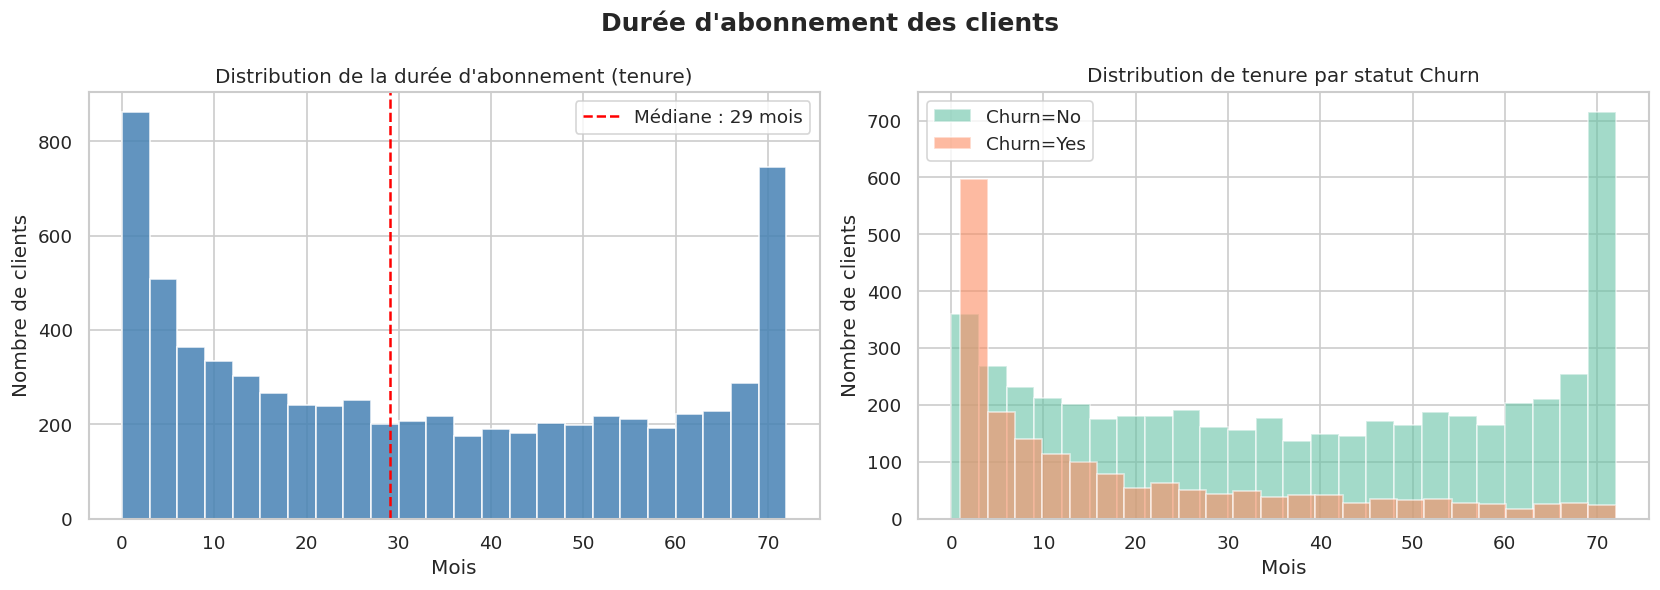

💡 Les clients qui churnent partent tôt : pic dans les 1-12 premiers mois.


In [ ]:
# --- Distribution de tenure par statut Churn ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['duration'], bins=24, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title("Distribution de la durée d'abonnement (tenure)")
axes[0].set_xlabel('Mois')
axes[0].set_ylabel('Nombre de clients')
axes[0].axvline(df['duration'].median(), color='red', linestyle='--', label=f'Médiane : {df["duration"].median():.0f} mois')
axes[0].legend()

for label, subset in df.groupby('Churn'):
    axes[1].hist(subset['duration'], bins=24, alpha=0.6, label=f'Churn={label}')
axes[1].set_title('Distribution de tenure par statut Churn')
axes[1].set_xlabel('Mois')
axes[1].set_ylabel('Nombre de clients')
axes[1].legend()

plt.suptitle("Durée d'abonnement des clients", fontsize=15, fontweight='bold')
plt.tight_layout()

import os
os.makedirs('../outputs/figures/', exist_ok=True) # Create the directory if it doesn't exist
plt.savefig('../outputs/figures/01_distribution_tenure.png', bbox_inches='tight')
plt.show()

print('💡 Les clients qui churnent partent tôt : pic dans les 1-12 premiers mois.')

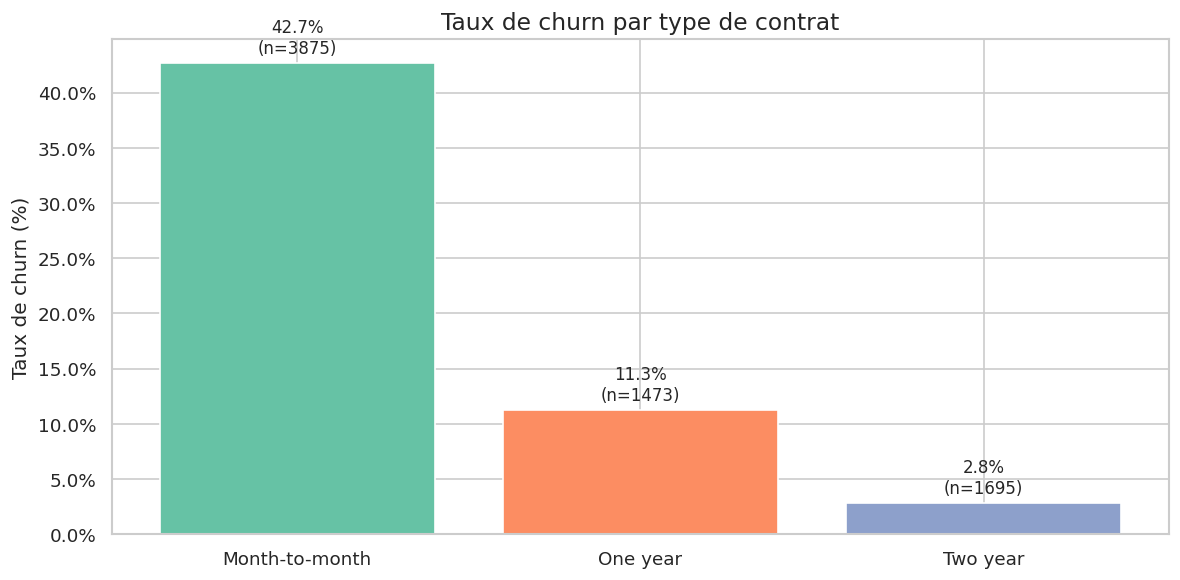

💡 Contrat mensuel = taux de churn dramatiquement plus élevé.
💡 Contrat 2 ans = fidélité très forte → la durée contractuelle fixe la rétention.


In [ ]:
# --- Churn par type de contrat ---
fig, ax = plt.subplots(figsize=(10, 5))

churn_contract = df.groupby('Contract')['event'].agg(['mean', 'count']).reset_index()
churn_contract['mean'] = churn_contract['mean'] * 100
churn_contract = churn_contract.sort_values('mean', ascending=False)

bars = ax.bar(churn_contract['Contract'], churn_contract['mean'],
              color=sns.color_palette('Set2', len(churn_contract)))
ax.set_title('Taux de churn par type de contrat', fontsize=14)
ax.set_ylabel('Taux de churn (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

for bar, (_, row) in zip(bars, churn_contract.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{row["mean"]:.1f}%\n(n={row["count"]})', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/figures/02_churn_par_contrat.png', bbox_inches='tight')
plt.show()

print('💡 Contrat mensuel = taux de churn dramatiquement plus élevé.')
print('💡 Contrat 2 ans = fidélité très forte → la durée contractuelle fixe la rétention.')

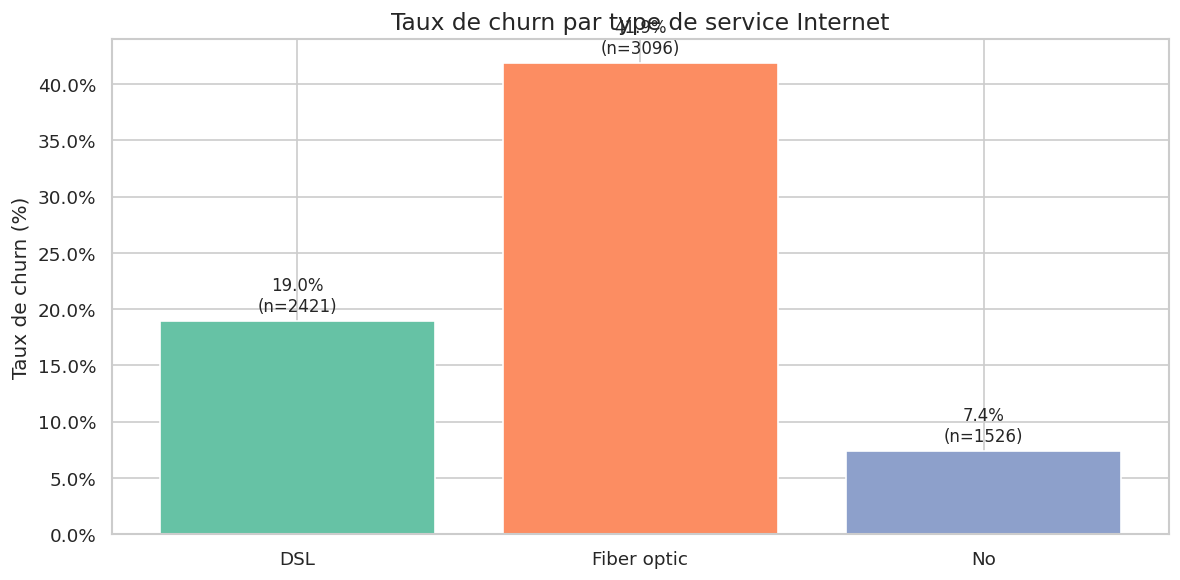

💡 Fibre optique = churn élevé malgré une meilleure offre → signal de pricing ou insatisfaction.


In [ ]:
# --- Churn par service Internet ---
fig, ax = plt.subplots(figsize=(10, 5))

churn_internet = df.groupby('InternetService')['event'].agg(['mean', 'count']).reset_index()
churn_internet['mean'] = churn_internet['mean'] * 100

bars = ax.bar(churn_internet['InternetService'], churn_internet['mean'],
              color=sns.color_palette('Set2', len(churn_internet)))
ax.set_title('Taux de churn par type de service Internet', fontsize=14)
ax.set_ylabel('Taux de churn (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

for bar, (_, row) in zip(bars, churn_internet.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{row["mean"]:.1f}%\n(n={row["count"]})', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/figures/03_churn_par_internet.png', bbox_inches='tight')
plt.show()

print('💡 Fibre optique = churn élevé malgré une meilleure offre → signal de pricing ou insatisfaction.')

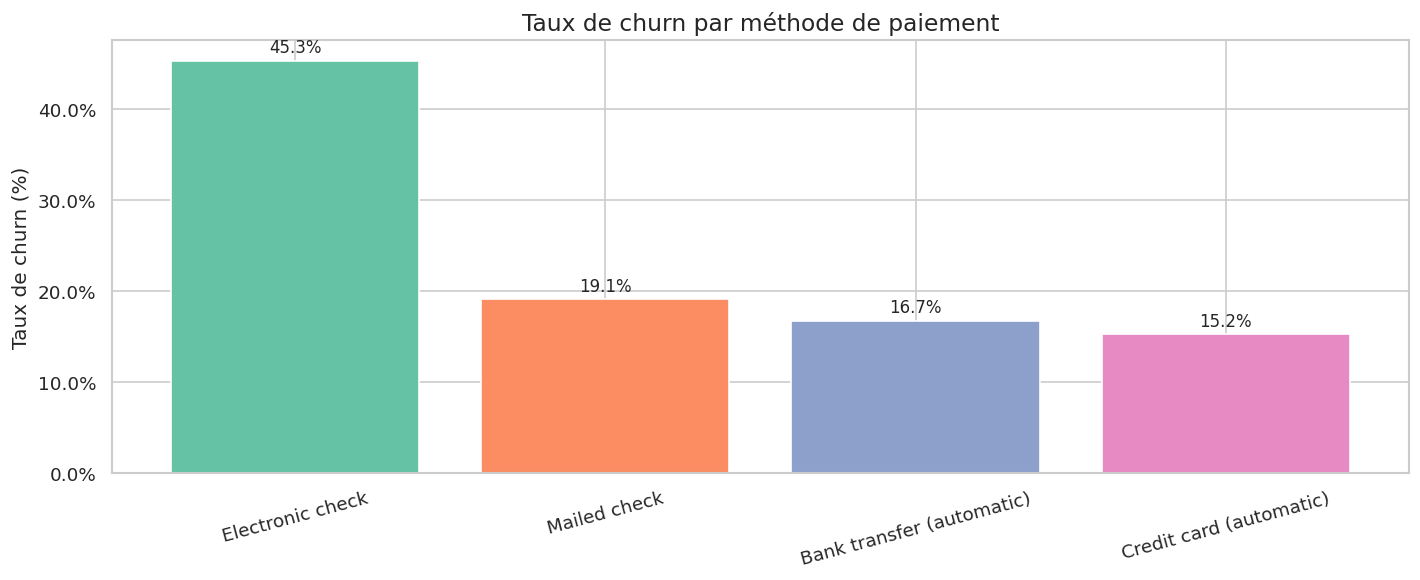

💡 Electronic check = churn le plus élevé → profil d'engagement faible.
💡 Paiement automatique (Bank transfer / Credit card) = meilleure rétention.


In [ ]:
# --- Churn par méthode de paiement ---
fig, ax = plt.subplots(figsize=(12, 5))

churn_payment = df.groupby('PaymentMethod')['event'].agg(['mean', 'count']).reset_index()
churn_payment['mean'] = churn_payment['mean'] * 100
churn_payment = churn_payment.sort_values('mean', ascending=False)

bars = ax.bar(churn_payment['PaymentMethod'], churn_payment['mean'],
              color=sns.color_palette('Set2', len(churn_payment)))
ax.set_title('Taux de churn par méthode de paiement', fontsize=14)
ax.set_ylabel('Taux de churn (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.xticks(rotation=15)

for bar, (_, row) in zip(bars, churn_payment.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{row["mean"]:.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/figures/04_churn_par_paiement.png', bbox_inches='tight')
plt.show()

print('💡 Electronic check = churn le plus élevé → profil d\'engagement faible.')
print('💡 Paiement automatique (Bank transfer / Credit card) = meilleure rétention.')

/tmp/ipykernel_4977/3610116530.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[0], palette='Set2')
/tmp/ipykernel_4977/3610116530.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Churn', y='TotalCharges', ax=axes[1], palette='Set2')


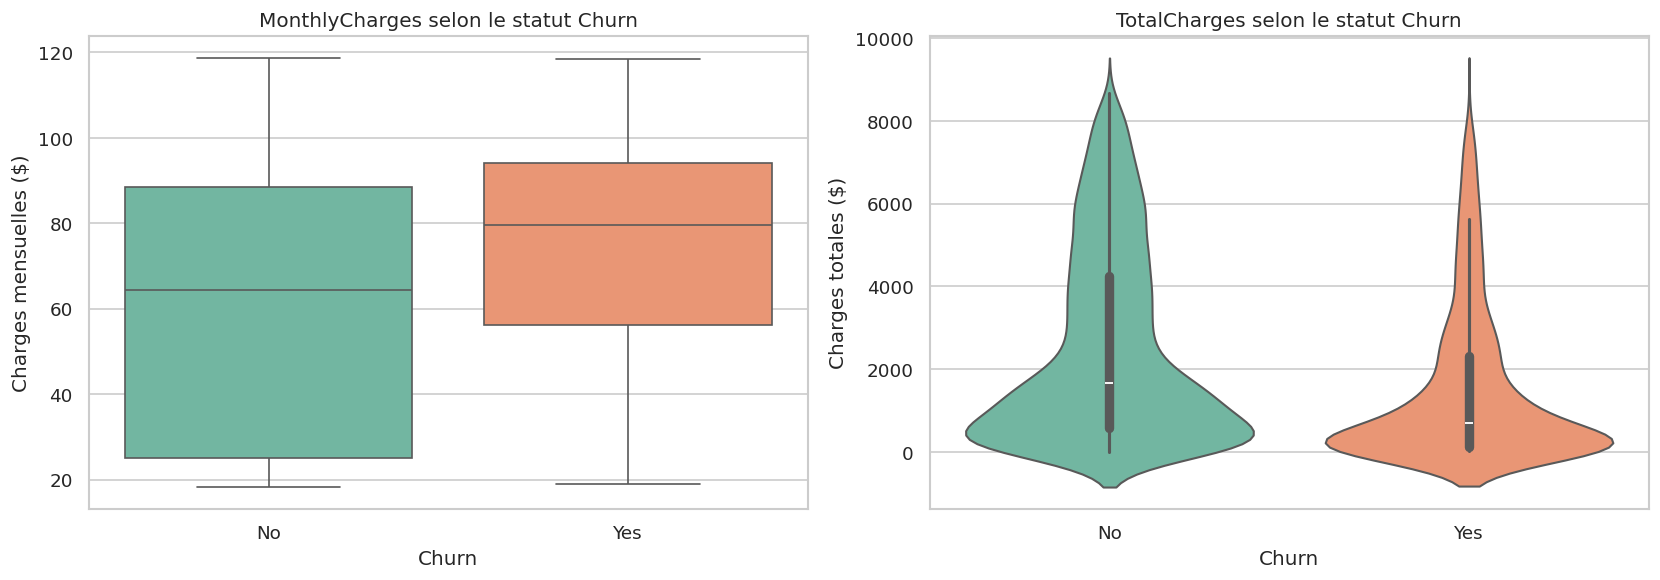

💡 Les churners paient plus par mois mais moins en total → ils partent trop tôt.


In [ ]:
# --- MonthlyCharges et TotalCharges vs Churn ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df, x='Churn', y='MonthlyCharges', ax=axes[0], palette='Set2')
axes[0].set_title('MonthlyCharges selon le statut Churn')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Charges mensuelles ($)')

sns.violinplot(data=df, x='Churn', y='TotalCharges', ax=axes[1], palette='Set2')
axes[1].set_title('TotalCharges selon le statut Churn')
axes[1].set_xlabel('Churn')
axes[1].set_ylabel('Charges totales ($)')

plt.tight_layout()
plt.savefig('../outputs/figures/05_charges_vs_churn.png', bbox_inches='tight')
plt.show()

print('💡 Les churners paient plus par mois mais moins en total → ils partent trop tôt.')

/tmp/ipykernel_4977/3893967207.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Non Senior (0)', 'Senior (1)'])


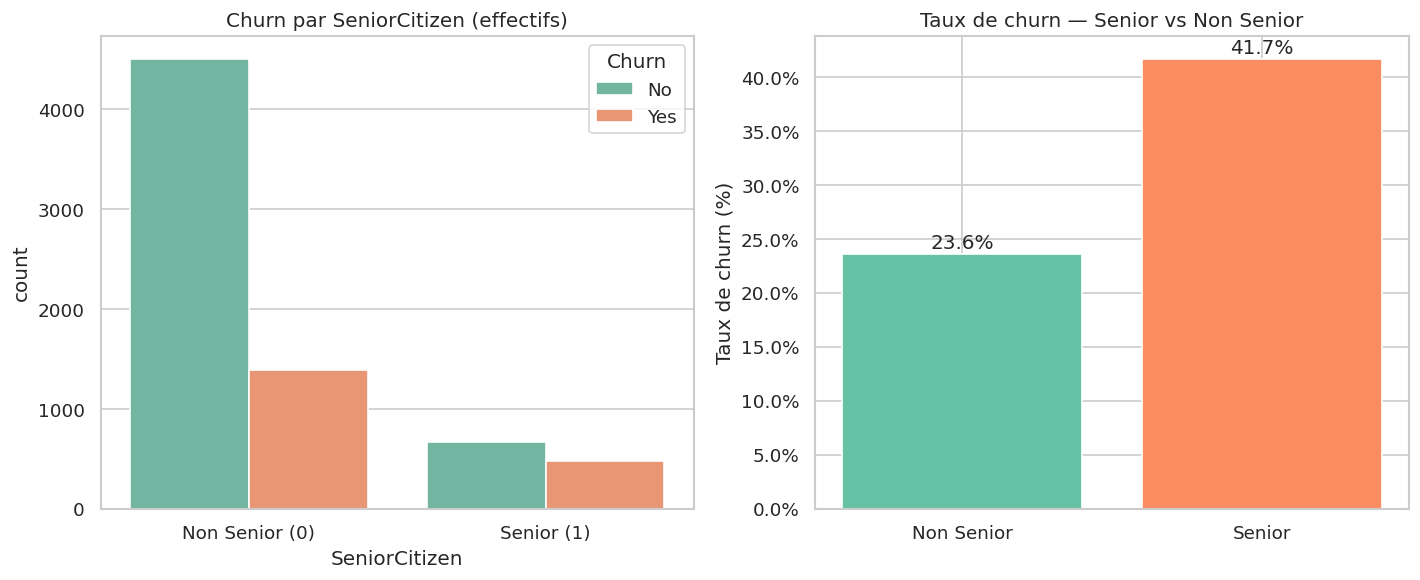

💡 Les seniors ont un taux de churn nettement plus élevé → segment prioritaire.


In [ ]:
# --- Churn par SeniorCitizen ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='SeniorCitizen', hue='Churn', ax=axes[0], palette='Set2')
axes[0].set_title('Churn par SeniorCitizen (effectifs)')
axes[0].set_xticklabels(['Non Senior (0)', 'Senior (1)'])

churn_senior = df.groupby('SeniorCitizen')['event'].mean() * 100
axes[1].bar(['Non Senior', 'Senior'], churn_senior.values,
            color=sns.color_palette('Set2', 2))
axes[1].set_title('Taux de churn — Senior vs Non Senior')
axes[1].set_ylabel('Taux de churn (%)')
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())

for i, v in enumerate(churn_senior.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center')

plt.tight_layout()
plt.savefig('../outputs/figures/06_churn_senior.png', bbox_inches='tight')
plt.show()

print('💡 Les seniors ont un taux de churn nettement plus élevé → segment prioritaire.')

## Analyse Kaplan-Meier globale

L'estimateur **Kaplan-Meier** est la méthode non-paramétrique de référence en survival analysis.
Il estime la **probabilité de survie** à chaque instant *t* en tenant compte des observations censurées.

Lecture : *"À t=12 mois, il y a X% de probabilité qu'un client soit encore actif."*

Avantage clé vs classification : les clients encore actifs ne sont pas traités comme des
"non-churners définitifs" — leur observation est censurée et leur information est exploitée.

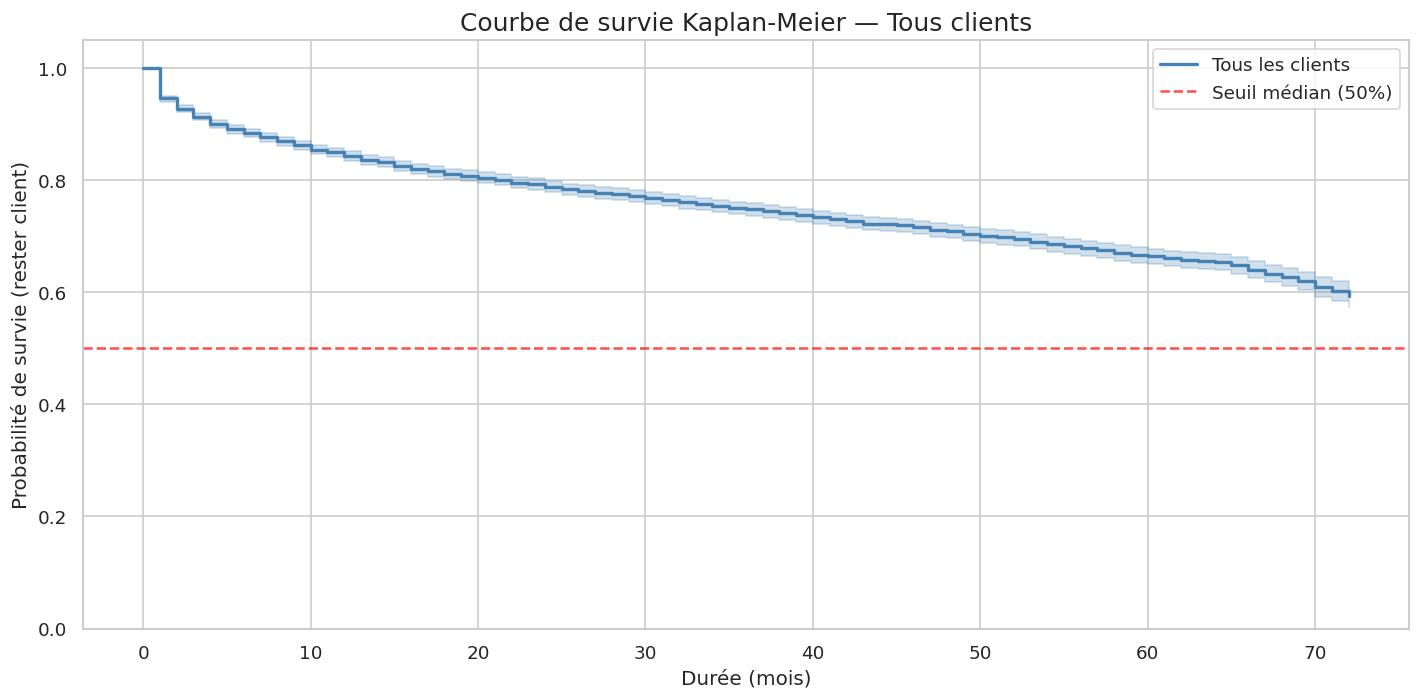

In [ ]:
# Initialisation et ajustement du modèle Kaplan-Meier
kmf = KaplanMeierFitter()
kmf.fit(durations=df['duration'], event_observed=df['event'], label='Tous les clients')

# Tracé de la courbe de survie globale
fig, ax = plt.subplots(figsize=(12, 6))

kmf.plot_survival_function(
    ax=ax,
    ci_show=True,        # intervalle de confiance à 95%
    color='steelblue',
    linewidth=2
)

ax.set_title('Courbe de survie Kaplan-Meier — Tous clients', fontsize=15)
ax.set_xlabel('Durée (mois)')
ax.set_ylabel('Probabilité de survie (rester client)')
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='red', linestyle='--', alpha=0.7, label='Seuil médian (50%)')
ax.legend()

plt.tight_layout()
plt.savefig('../outputs/figures/07_kaplan_meier_global.png', bbox_inches='tight')
plt.show()

In [ ]:
# Probabilités de survie à des jalons clés
jalons = [6, 12, 24, 36, 48]

print('=== Probabilités de survie Kaplan-Meier ===')
print(f'{"Jalon (mois)":>15} | {"P(survie)":>12}')
print('-' * 32)

for t in jalons:
    sf = kmf.survival_function_at_times(t).values[0]
    print(f'{t:>15} | {sf:>11.1%}')

print(f'\nMédiane de survie : {kmf.median_survival_time_:.0f} mois')
print('→ La médiane de survie est infine dans la fenêtre dobservation, car plus de 50% des clients sont encore actifs jusqua la fin de la période observée.')

=== Probabilités de survie Kaplan-Meier ===
   Jalon (mois) |    P(survie)
--------------------------------
              6 |       88.5%
             12 |       84.3%
             24 |       78.9%
             36 |       74.9%
             48 |       70.9%

Médiane de survie : inf mois
→ La médiane de survie est infine dans la fenêtre dobservation, car plus de 50% des clients sont encore actifs jusqua la fin de la période observée.


In [ ]:
print("""
Lecture business de la courbe Kaplan-Meier :

  • La courbe est décroissante : plus le temps passe, moins il reste de clients actifs.
  • La pente est la plus forte dans les 12 premiers mois → période critique de rétention.
  • Passé 24 mois, la courbe se stabilise : les clients fidèles ont tendance à le rester.
  • La zone bleue (IC 95%) mesure l'incertitude de l'estimation.

  Dans le cas de First-id : on pourrait dire que cette courbe mesure la durée de vie
     d'un profil avant inactivité, en intégrant les profils non encore disparus (censurés).
""")


Lecture business de la courbe Kaplan-Meier :

  • La courbe est décroissante : plus le temps passe, moins il reste de clients actifs.
  • La pente est la plus forte dans les 12 premiers mois → période critique de rétention.
  • Passé 24 mois, la courbe se stabilise : les clients fidèles ont tendance à le rester.
  • La zone bleue (IC 95%) mesure l'incertitude de l'estimation.

  Dans le cas de First-id : on pourrait dire que cette courbe mesure la durée de vie
     d'un profil avant inactivité, en intégrant les profils non encore disparus (censurés).



## Analyse Kaplan-Meier par segments

On compare les courbes de survie pour différents sous-groupes.
Visuellement, plus les courbes sont éloignées, plus les groupes se comportent différemment.
La significativité statistique sera vérifiée en section 9 avec les tests Log-Rank.

In [ ]:
def plot_km_by_segment(df, col, ax, title=None):
    """
    Trace les courbes Kaplan-Meier pour chaque modalité d'une variable catégorielle.

    Paramètres :
    ------------
    df    : DataFrame avec colonnes 'duration', 'event' et `col`
    col   : variable de segmentation (catégorielle)
    ax    : axe matplotlib sur lequel tracer
    title : titre du graphique (optionnel)
    """
    kmf_seg = KaplanMeierFitter()
    palette = sns.color_palette('Set2', df[col].nunique())

    for i, (label, subset) in enumerate(df.groupby(col)):
        kmf_seg.fit(
            durations=subset['duration'],
            event_observed=subset['event'],
            label=str(label)
        )
        kmf_seg.plot_survival_function(ax=ax, ci_show=False,
                                       color=palette[i], linewidth=2)

    ax.set_title(title or f'KM par {col}', fontsize=13)
    ax.set_xlabel('Durée (mois)')
    ax.set_ylabel('P(survie)')
    ax.set_ylim(0, 1.05)
    ax.legend(loc='upper right')

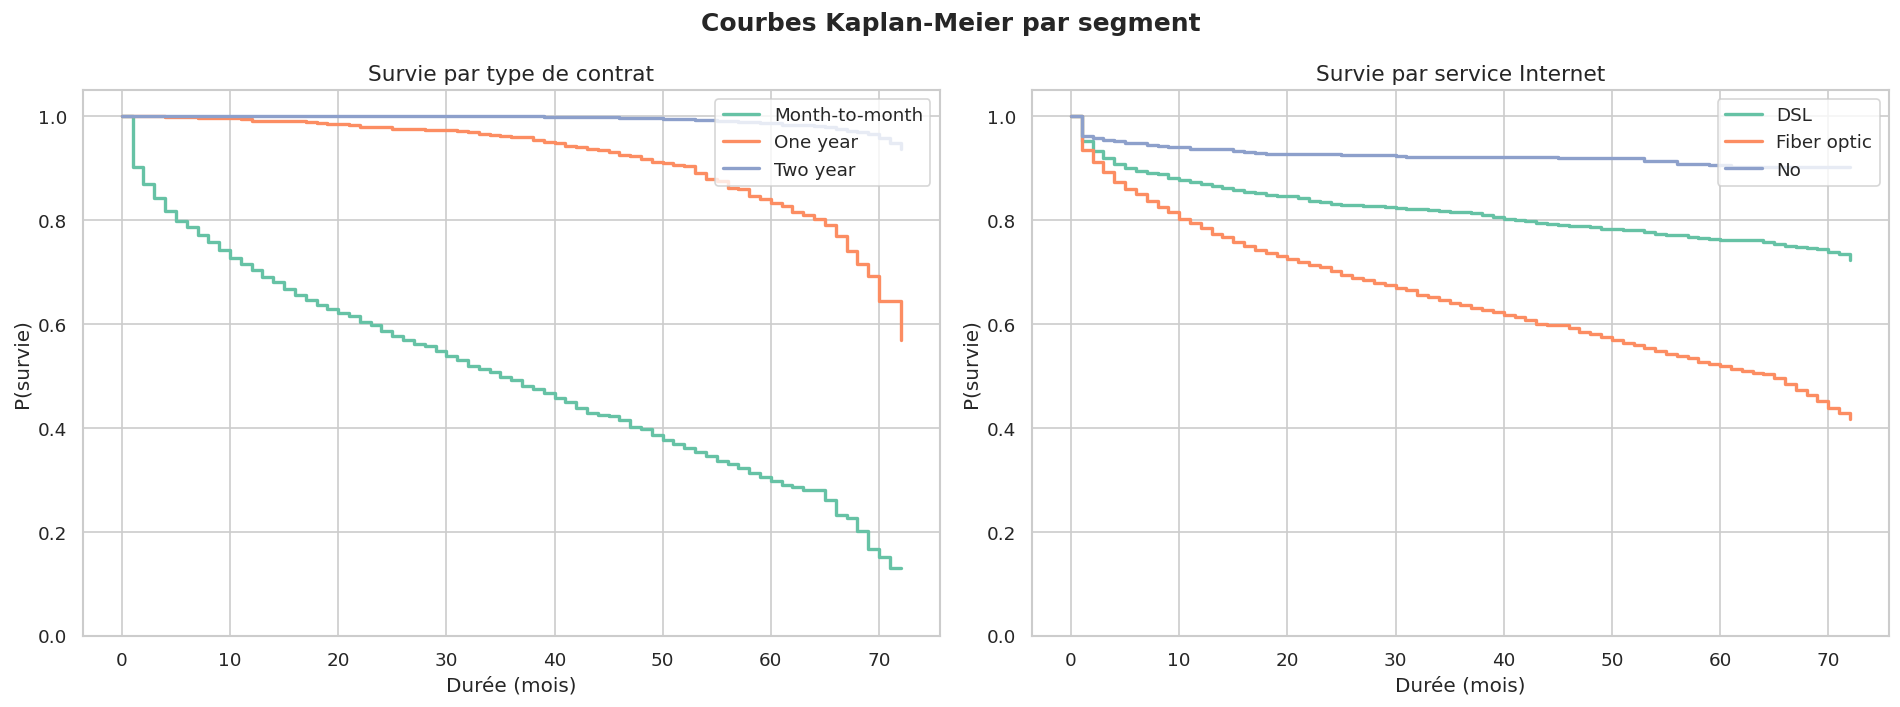

💡 Contrat Two year : courbe quasi plate → rétention quasi totale.
💡 Fibre optique : chute rapide malgré la qualité de service → signal pricing ou attentes.


In [ ]:
# --- KM par Contract et InternetService ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_km_by_segment(df, 'Contract', axes[0], 'Survie par type de contrat')
plot_km_by_segment(df, 'InternetService', axes[1], 'Survie par service Internet')

plt.suptitle('Courbes Kaplan-Meier par segment', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/08_km_contract_internet.png', bbox_inches='tight')
plt.show()

print('💡 Contrat Two year : courbe quasi plate → rétention quasi totale.')
print('💡 Fibre optique : chute rapide malgré la qualité de service → signal pricing ou attentes.')

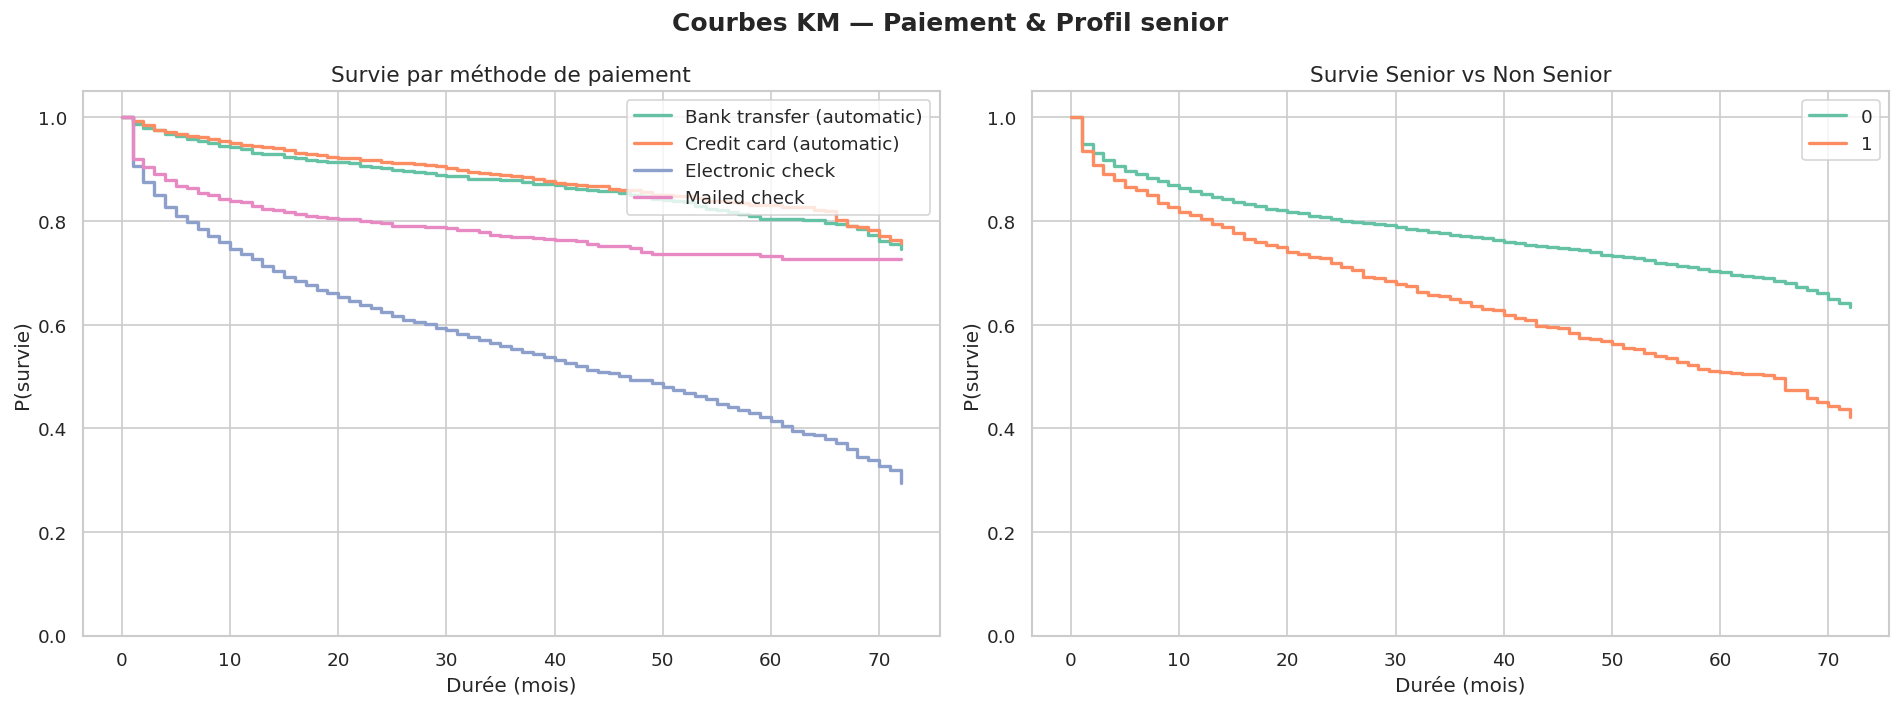

💡 Paiement automatique (domiciliation) = bien meilleure survie.
💡 Seniors : chute plus rapide dès les premiers mois.


In [ ]:
# --- KM par PaymentMethod et SeniorCitizen ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_km_by_segment(df, 'PaymentMethod', axes[0], 'Survie par méthode de paiement')
plot_km_by_segment(df, 'SeniorCitizen', axes[1], 'Survie Senior vs Non Senior')

plt.suptitle('Courbes KM — Paiement & Profil senior', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/09_km_payment_senior.png', bbox_inches='tight')
plt.show()

print('💡 Paiement automatique (domiciliation) = bien meilleure survie.')
print('💡 Seniors : chute plus rapide dès les premiers mois.')

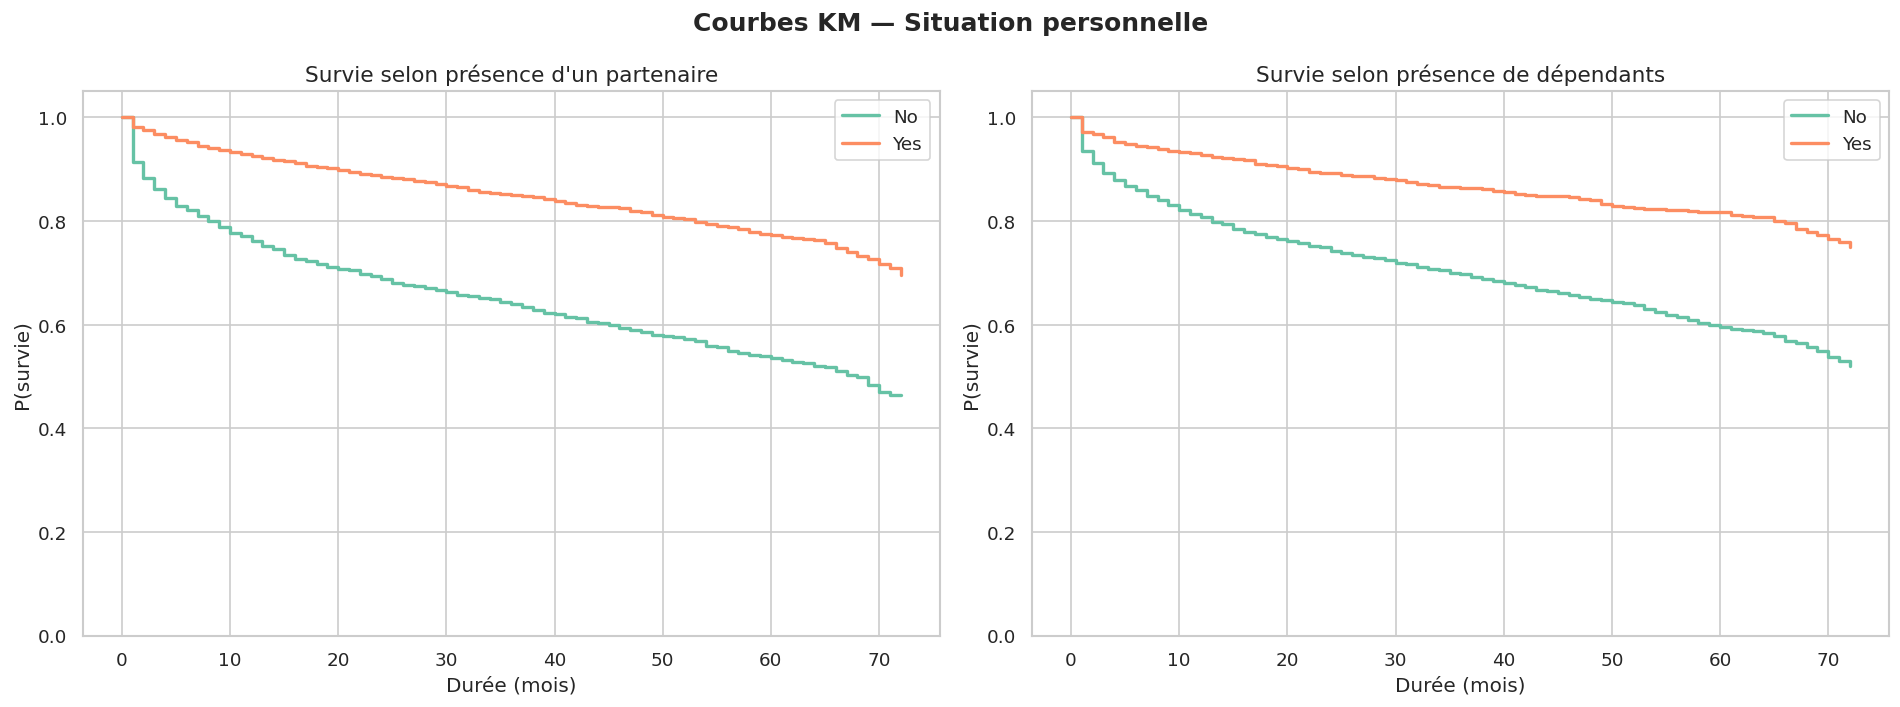

💡 Partenaire / dépendants = durée de vie plus longue → l'ancrage familial stabilise l'abonnement.


In [ ]:
# --- KM par Partner et Dependents ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_km_by_segment(df, 'Partner', axes[0], "Survie selon présence d'un partenaire")
plot_km_by_segment(df, 'Dependents', axes[1], 'Survie selon présence de dépendants')

plt.suptitle('Courbes KM — Situation personnelle', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/10_km_partner_dependents.png', bbox_inches='tight')
plt.show()

print("💡 Partenaire / dépendants = durée de vie plus longue → l'ancrage familial stabilise l'abonnement.")

## Tests statistiques Log-Rank

Le **test Log-Rank** vérifie si les différences observées entre courbes de survie
sont **statistiquement significatives** ou dues au hasard.

- H₀ : les courbes de survie sont identiques entre les groupes
- Si **p-value < 0.05** → on rejette H₀ → les différences sont significatives

In [ ]:
def run_logrank_test(df, col, duration_col='duration', event_col='event'):
    """
    Effectue le test Log-Rank pour une variable catégorielle.
    Utilise logrank_test (2 groupes) ou multivariate_logrank_test (>2 groupes).
    """
    groups = df[col].unique()
    n_groups = len(groups)

    if n_groups == 2:
        g1, g2 = groups
        s1 = df[df[col] == g1]
        s2 = df[df[col] == g2]
        result = logrank_test(
            s1[duration_col], s2[duration_col],
            event_observed_A=s1[event_col],
            event_observed_B=s2[event_col]
        )
    else:
        result = multivariate_logrank_test(df[duration_col], df[col], df[event_col])

    pval = result.p_value
    signif = '✅ Significatif' if pval < 0.05 else '❌ Non significatif'
    return pval, n_groups, signif

In [ ]:
variables_test = ['Contract', 'InternetService', 'PaymentMethod',
                  'SeniorCitizen', 'Partner', 'Dependents']

print(f'{"Variable":<20} | {"Groupes":>7} | {"p-value":>12} | {"Résultat"}')
print('-' * 65)

results_logrank = []
for col in variables_test:
    pval, n_groups, signif = run_logrank_test(df, col)
    results_logrank.append({'Variable': col, 'Groupes': n_groups,
                            'p-value': pval, 'Résultat': signif})
    print(f'{col:<20} | {n_groups:>7} | {pval:>12.4f} | {signif}')

import os
os.makedirs('../outputs/tables/', exist_ok=True)
pd.DataFrame(results_logrank).to_csv('../outputs/tables/logrank_results.csv', index=False)
print('\n📁 Résultats sauvegardés → outputs/tables/logrank_results.csv')

Variable             | Groupes |      p-value | Résultat
-----------------------------------------------------------------
Contract             |       3 |       0.0000 | ✅ Significatif
InternetService      |       3 |       0.0000 | ✅ Significatif
PaymentMethod        |       4 |       0.0000 | ✅ Significatif
SeniorCitizen        |       2 |       0.0000 | ✅ Significatif
Partner              |       2 |       0.0000 | ✅ Significatif
Dependents           |       2 |       0.0000 | ✅ Significatif

📁 Résultats sauvegardés → outputs/tables/logrank_results.csv


In [ ]:
print("""
💡 Interprétation :

  • Toutes les variables ont une p-value << 0.05.
  • Les différences de survie entre segments ne sont pas dues au hasard.
  • La segmentation est statistiquement robuste → elle peut guider des décisions business.

  🏢 Implication First-id :
  → On peut segmenter les identifiants par attributs et confirmer statistiquement
     que certains types de profils disparaissent significativement plus vite.
""")


💡 Interprétation :

  • Toutes les variables ont une p-value << 0.05.
  • Les différences de survie entre segments ne sont pas dues au hasard.
  • La segmentation est statistiquement robuste → elle peut guider des décisions business.

  🏢 Implication First-id :
  → On peut segmenter les identifiants par attributs et confirmer statistiquement
     que certains types de profils disparaissent significativement plus vite.



## Modèle de Cox Proportional Hazards

Le modèle de **Cox** est un modèle semi-paramétrique qui estime l'impact de plusieurs
variables simultanément sur le **risque instantané de churn** (hazard function).

Le **Hazard Ratio (HR)** s'interprète ainsi :
- HR > 1 → la variable **augmente** le risque de churn
- HR < 1 → la variable **réduit** le risque de churn
- HR = 1 → aucun effet

Avantage vs logistic regression : Cox prend en compte le **temps**, les censures,
et modélise l'évolution du risque sur toute la durée de vie — pas seulement à un instant T.

In [ ]:
# Préparation des données pour Cox
# On retire l'identifiant client (non informative) et les colonnes sources
drop_cols = ['customerID', 'tenure', 'Churn']
df_cox = df.drop(columns=drop_cols, errors='ignore').copy()

# One-Hot Encoding des variables catégorielles
# drop_first=True : évite la multicolinéarité (variable de référence implicite)
cat_cols_cox = df_cox.select_dtypes(include='object').columns.tolist()
print(f'Variables catégorielles à encoder : {cat_cols_cox}')

df_cox = pd.get_dummies(df_cox, columns=cat_cols_cox, drop_first=True, dtype=int)

print(f'\nShape après encoding : {df_cox.shape}')
print('Colonnes finales :', df_cox.columns.tolist())

Variables catégorielles à encoder : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Shape après encoding : (7043, 31)
Colonnes finales : ['SeniorCitizen', 'MonthlyCharges', 'TotalCharges', 'duration', 'event', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'Paym

In [ ]:
# Vérifications avant ajustement
assert 'duration' in df_cox.columns, 'Colonne duration manquante !'
assert 'event' in df_cox.columns, 'Colonne event manquante !'
print(f'✅ duration et event présents.')
print(f'NaN dans df_cox : {df_cox.isnull().sum().sum()}')

✅ duration et event présents.
NaN dans df_cox : 0


In [ ]:
# Ajustement du modèle de Cox
# penalizer=0.1 : légère régularisation L2 pour stabilité numérique
cph = CoxPHFitter(penalizer=0.1)

cph.fit(
    df_cox,
    duration_col='duration',
    event_col='event',
    show_progress=False
)

print('✅ Modèle de Cox ajusté.')

✅ Modèle de Cox ajusté.


In [ ]:
# Résumé complet du modèle
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>
             duration col = 'duration'
                event col = 'event'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 7043
number of events observed = 1869
   partial log-likelihood = -13928.34
         time fit was run = 2026-06-01 16:24:15 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                              
SeniorCitizen                          0.05      1.05      0.05           -0.05            0.14                0.95                1.15
MonthlyCharges                         0.00      1.00      0.00            0.00            0.01                1.00                1.01
TotalCharges                          -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
gender_Male                           -0.03      0.97      0.04           -0.11            0.04                0.89                1.04
Partner_Yes                           -0.31      0.73      0.04           -0.39           -0.23                0.67                0.80
Dependents_Yes                        -0.15      0.86      0.05           -0.25           -0.05                0.78                0.95
PhoneService_Yes                       0.11      1.12      0.10           -0.08            0.31                0.92                1.36
MultipleLines_No phone service        -0.11      0.90      0.10           -0.31            0.08                0.74                1.09
MultipleLines_Yes                     -0.15      0.86      0.04           -0.24           -0.07                0.79                0.94
InternetService_Fiber optic            0.47      1.60      0.05            0.37            0.58                1.45                1.78
InternetService_No                    -0.22      0.80      0.09           -0.39           -0.06                0.68                0.95
OnlineSecurity_No internet service    -0.22      0.80      0.09           -0.39           -0.06                0.68                0.95
OnlineSecurity_Yes                    -0.43      0.65      0.05           -0.52           -0.33                0.59                0.72
OnlineBackup_No internet service      -0.22      0.80      0.09           -0.39           -0.06                0.68                0.95
OnlineBackup_Yes                      -0.31      0.73      0.04           -0.40           -0.23                0.67                0.80
DeviceProtection_No internet service  -0.22      0.80      0.09           -0.39           -0.06                0.68                0.95
DeviceProtection_Yes                  -0.18      0.83      0.05           -0.27           -0.09                0.76                0.91
TechSupport_No internet service       -0.22      0.80      0.09           -0.39           -0.06                0.68                0.95
TechSupport_Yes                       -0.34      0.71      0.05           -0.43           -0.24                0.65                0.79
StreamingTV_No internet service       -0.22      0.80      0.09           -0.39           -0.06                0.68                0.95
StreamingTV_Yes                        0.04      1.04      0.04           -0.05            0.12                0.95                1.13
StreamingMovies_No internet service   -0.22      0.80      0.09           -0.39           -0.06                0.68                0.95
StreamingMovies_Yes                    0.01      1.01      0.04           -0.08            0.10                0.92                1.10
Contract_One year                     -0.67      0.51      0.06           -0.78           -0.55                0.46                0.58
Contract_Two year                

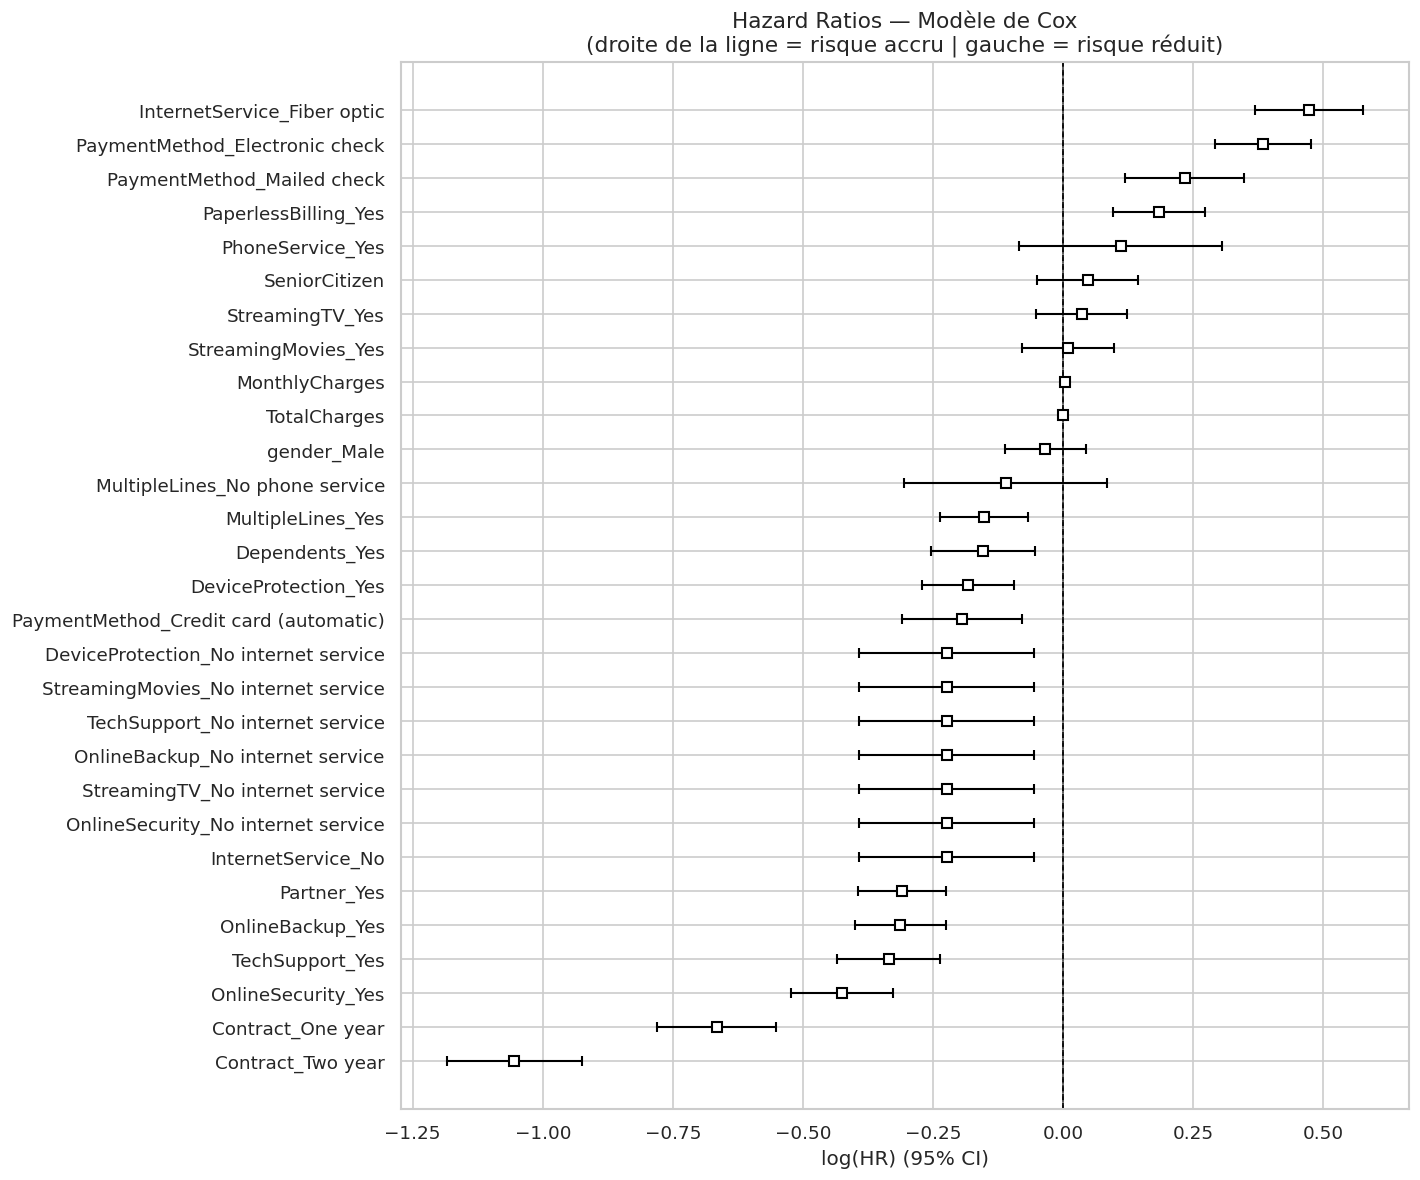

In [ ]:
# Visualisation des Hazard Ratios
fig, ax = plt.subplots(figsize=(12, 10))
cph.plot(ax=ax)
ax.set_title('Hazard Ratios — Modèle de Cox\n(droite de la ligne = risque accru | gauche = risque réduit)',
             fontsize=13)
ax.axvline(0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('../outputs/figures/11_cox_hazard_ratios.png', bbox_inches='tight')
plt.show()

In [ ]:
# Extraction et tri des variables par impact sur le churn
summary = cph.summary.copy()
summary['HR'] = np.exp(summary['coef'])   # Hazard Ratio
summary_sorted = summary[['coef', 'HR', 'p']].sort_values('coef', ascending=False)

summary_sorted.to_csv('../outputs/tables/cox_summary.csv')

print('=== Variables qui AUGMENTENT le risque de churn (HR > 1) ===')
for idx, row in summary_sorted[summary_sorted['coef'] > 0].head(8).iterrows():
    print(f'  {idx:<45} HR = {row["HR"]:.2f}  (p={row["p"]:.4f})')

print('\n=== Variables qui RÉDUISENT le risque de churn (HR < 1) ===')
for idx, row in summary_sorted[summary_sorted['coef'] < 0].tail(8).iterrows():
    print(f'  {idx:<45} HR = {row["HR"]:.2f}  (p={row["p"]:.4f})')

=== Variables qui AUGMENTENT le risque de churn (HR > 1) ===
  InternetService_Fiber optic                   HR = 1.60  (p=0.0000)
  PaymentMethod_Electronic check                HR = 1.47  (p=0.0000)
  PaymentMethod_Mailed check                    HR = 1.26  (p=0.0001)
  PaperlessBilling_Yes                          HR = 1.20  (p=0.0000)
  PhoneService_Yes                              HR = 1.12  (p=0.2657)
  SeniorCitizen                                 HR = 1.05  (p=0.3413)
  StreamingTV_Yes                               HR = 1.04  (p=0.4307)
  StreamingMovies_Yes                           HR = 1.01  (p=0.8373)

=== Variables qui RÉDUISENT le risque de churn (HR < 1) ===
  TechSupport_No internet service               HR = 0.80  (p=0.0092)
  StreamingTV_No internet service               HR = 0.80  (p=0.0092)
  Partner_Yes                                   HR = 0.73  (p=0.0000)
  OnlineBackup_Yes                              HR = 0.73  (p=0.0000)
  TechSupport_Yes                     

In [ ]:
print("""
💡 Interprétation business des Hazard Ratios :

  Facteurs de risque (HR >> 1) :
  → Contract_Month-to-month : le contrat mensuel est le principal levier de churn.
  → PaymentMethod_Electronic check : paiement instable = profil peu engagé.
  → InternetService_Fiber optic : paradoxe fibre → attentes non comblées ou prix élevé.

  Facteurs protecteurs (HR << 1) :
  → Contract_Two year : engagement long terme = protection massive contre le churn.
  → MonthlyCharges, tenure : l'ancienneté et l'habitude réduisent le risque résiduel.

  🏢 Parallèle First-id :
  → Chaque HR correspond à l'impact d'un attribut d'identifiant dans le graphe.
  → HR élevé = signal prédictif d'inactivité pour ce type de profil.
""")


💡 Interprétation business des Hazard Ratios :

  Facteurs de risque (HR >> 1) :
  → Contract_Month-to-month : le contrat mensuel est le principal levier de churn.
  → PaymentMethod_Electronic check : paiement instable = profil peu engagé.
  → InternetService_Fiber optic : paradoxe fibre → attentes non comblées ou prix élevé.

  Facteurs protecteurs (HR << 1) :
  → Contract_Two year : engagement long terme = protection massive contre le churn.
  → MonthlyCharges, tenure : l'ancienneté et l'habitude réduisent le risque résiduel.

  🏢 Parallèle First-id :
  → Chaque HR correspond à l'impact d'un attribut d'identifiant dans le graphe.
  → HR élevé = signal prédictif d'inactivité pour ce type de profil.



## Validation et performance du modèle

In [ ]:
# --- Concordance Index (C-index) ---
# Mesure la capacité du modèle à ordonner correctement les risques relatifs.
# C-index = 0.5 → aléatoire | C-index = 1.0 → parfait
# En pratique : > 0.70 = bon, > 0.75 = excellent

c_index = cph.concordance_index_
print(f'📊 Concordance Index (C-index) : {c_index:.4f}')

interpretation = ('Excellent' if c_index > 0.75 else
                  'Bon'       if c_index > 0.65 else
                  'Modéré'    if c_index > 0.55 else 'Faible')

print(f'   Interprétation : {interpretation}')
print(f'   → Le modèle prédit correctement l\'ordre des risques dans {c_index:.0%} des paires.')

📊 Concordance Index (C-index) : 0.9029
   Interprétation : Excellent
   → Le modèle prédit correctement l'ordre des risques dans 90% des paires.


In [ ]:
# --- Vérification de l'hypothèse de proportionnalité ---
# L'hypothèse PH suppose que les Hazard Ratios sont constants dans le temps.
# On la vérifie via les résidus de Schoenfeld.

try:
    cph.check_assumptions(df_cox, p_value_threshold=0.05, show_plots=False)
    print('✅ Test de l\'hypothèse PH effectué.')
except Exception as e:
    print(f'ℹ️ Test PH : {e}')
    print('→ Solutions si violation : stratifier le modèle Cox, ou utiliser')
    print('  des covariables dépendantes du temps (time-varying covariates).')

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'MonthlyCharges' failed the non-proportional test: p-value is 0.0111.

   Advice 1: the functional form of the variable 'MonthlyCharges' might be incorrect. That is, there
may be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'MonthlyCharges' using pd.cut, and then specify it in
`strata=['MonthlyCharges', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


2. Variable 'TotalCharges' failed the non-proportional test: p-value is 0.0244.

   Advice 1: the functional form of the variable 'TotalCharges' might be incorrect. That is, there
may be non-linear terms missing. The proportional hazard test used is very sensitive to incorrect
functional forms. See documentation in link [D] belo

In [ ]:
print("""
⚠️ Limites du modèle à mentionner en entretien :

  1. Hypothèse de proportionnalité parfois violée (notamment pour Contract)
     → L'effet du contrat varie dans le temps, pas uniquement en magnitude constante.

  2. Dataset statique : on n'a qu'une photo à un instant T.
     En production, les variables évoluent (changement de plan, upgrade, etc.)

  3. Censure supposée non-informative : les clients encore actifs ne sont
     pas supposés différents des autres — hypothèse à valider sur données réelles.

  4. Données fictives : les résultats sont illustratifs, non directement
     transposables à un opérateur réel.
""")


⚠️ Limites du modèle à mentionner en entretien :

  1. Hypothèse de proportionnalité parfois violée (notamment pour Contract)
     → L'effet du contrat varie dans le temps, pas uniquement en magnitude constante.

  2. Dataset statique : on n'a qu'une photo à un instant T.
     En production, les variables évoluent (changement de plan, upgrade, etc.)

  3. Censure supposée non-informative : les clients encore actifs ne sont
     pas supposés différents des autres — hypothèse à valider sur données réelles.

  4. Données fictives : les résultats sont illustratifs, non directement
     transposables à un opérateur réel.



## Profils clients et prédiction de survie individuelle

Le modèle de Cox permet de prédire la courbe de survie d'un individu donné
selon ses caractéristiques. On construit ici trois profils types pour illustrer
l'étendue des risques.

In [ ]:
# Template de base = valeurs médianes du dataset encodé
template = pd.DataFrame([df_cox.drop(columns=['duration', 'event']).median().to_dict()])

# --- Profil 1 : Faible risque ---
# Contrat 2 ans, paiement automatique, pas senior, avec partenaire
profile_low = template.copy()
for col in df_cox.columns:
    if 'Contract_Two year'             in col: profile_low[col] = 1
    if 'Contract_One year'             in col: profile_low[col] = 0
    if 'PaymentMethod_Electronic check' in col: profile_low[col] = 0
    if 'InternetService_Fiber optic'   in col: profile_low[col] = 0
    if col == 'SeniorCitizen':                  profile_low[col] = 0
    if 'Partner_Yes'                   in col: profile_low[col] = 1

# --- Profil 2 : Risque élevé ---
# Contrat mensuel, electronic check, fibre, senior, sans partenaire
profile_high = template.copy()
for col in df_cox.columns:
    if 'Contract_Two year'             in col: profile_high[col] = 0
    if 'Contract_One year'             in col: profile_high[col] = 0
    if 'PaymentMethod_Electronic check' in col: profile_high[col] = 1
    if 'InternetService_Fiber optic'   in col: profile_high[col] = 1
    if col == 'SeniorCitizen':                  profile_high[col] = 1
    if 'Partner_Yes'                   in col: profile_high[col] = 0

# --- Profil 3 : Moyen (médiane) ---
profile_avg = template.copy()

print('✅ 3 profils créés.')

✅ 3 profils créés.


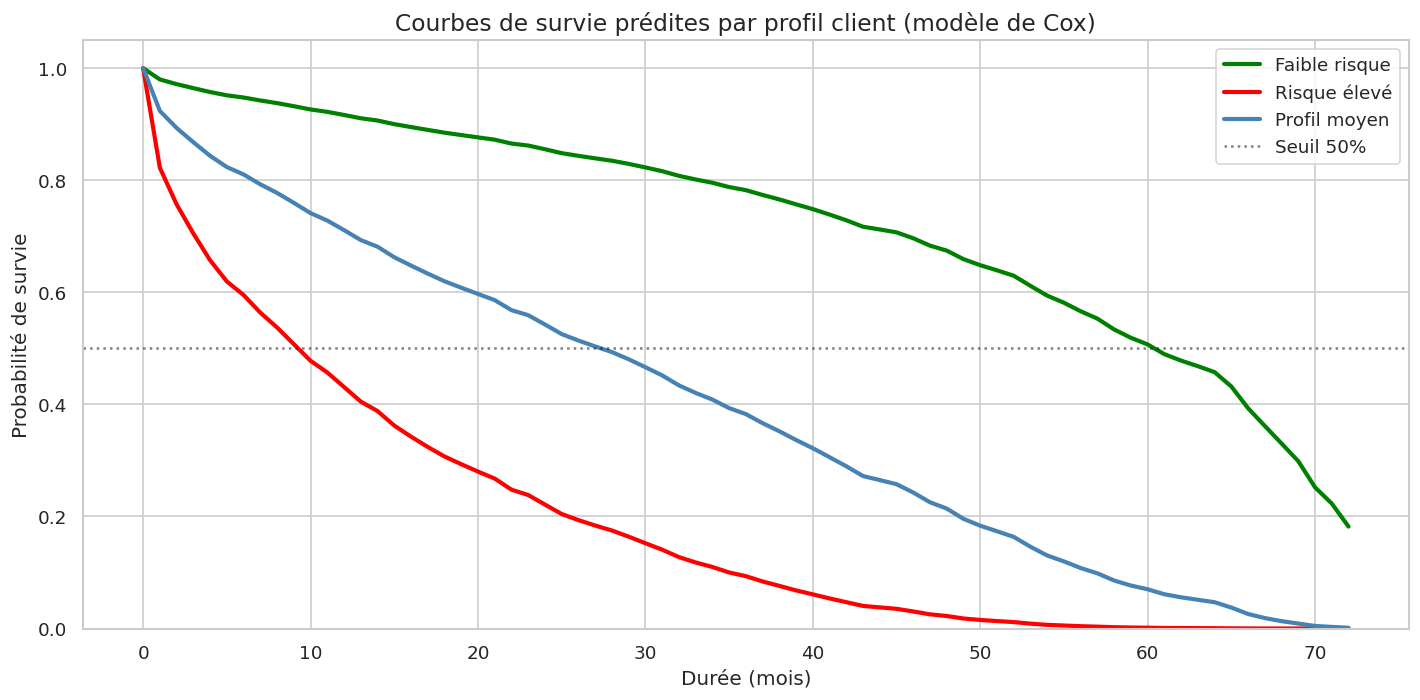

In [ ]:
# Prédiction et tracé des courbes de survie individuelles
fig, ax = plt.subplots(figsize=(12, 6))

profiles = [profile_low,       profile_high,       profile_avg]
labels   = ['Faible risque',   'Risque élevé',     'Profil moyen']
colors   = ['green',           'red',              'steelblue']

for profile, label, color in zip(profiles, labels, colors):
    sf = cph.predict_survival_function(profile)
    ax.plot(sf.index, sf.iloc[:, 0], color=color, linewidth=2.5, label=label)

ax.set_title('Courbes de survie prédites par profil client (modèle de Cox)', fontsize=14)
ax.set_xlabel('Durée (mois)')
ax.set_ylabel('Probabilité de survie')
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color='black', linestyle=':', alpha=0.5, label='Seuil 50%')
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('../outputs/figures/12_cox_profils_survie.png', bbox_inches='tight')
plt.show()

In [ ]:
# Probabilités de survie à 12 mois par profil
print('=== Probabilité d\'être encore client à 12 mois ===')
for profile, label in zip(profiles, labels):
    prob = cph.predict_survival_function(profile, times=[12]).iloc[0, 0]
    print(f'  {label:<25} : {prob:.1%}')

print("""
💡 L'écart entre profils est massif.
   → La survival analysis permet de quantifier individuellement le risque.
   → En production : chaque client/identifiant reçoit sa propre courbe → priorisation des actions.
""")

=== Probabilité d'être encore client à 12 mois ===
  Faible risque             : 91.7%
  Risque élevé              : 43.1%
  Profil moyen              : 71.1%

💡 L'écart entre profils est massif.
   → La survival analysis permet de quantifier individuellement le risque.
   → En production : chaque client/identifiant reçoit sa propre courbe → priorisation des actions.



## Insights finaux pour une équipe produit/business

In [ ]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║       RAPPORT FINAL — SURVIVAL ANALYSIS TELCO CHURN             ║
╚══════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 1. PRINCIPAUX ENSEIGNEMENTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  1️⃣  Le risque de churn est maximal dans les 12 premiers mois.
  2️⃣  Le type de contrat est le prédicteur le plus puissant de la rétention.
  3️⃣  Le mode de paiement reflète le niveau d'engagement du client.
  4️⃣  Les seniors churnent plus rapidement → segment vulnérable prioritaire.
  5️⃣  La fibre génère plus de churn que le DSL → signal de déception ou pricing.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🚨 2. SEGMENTS LES PLUS À RISQUE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  • Contrat mensuel + Fibre + Electronic check → risque maximal
  • Seniors sans partenaire ni dépendants → peu d'ancrage
  • Clients avec charges élevées et tenure < 12 mois

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🎯 3. RECOMMANDATIONS BUSINESS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  ✦ Inciter à basculer vers des contrats annuels (incentives, remises)
  ✦ Programme de fidélisation ciblé sur les 3 premiers mois
  ✦ Proposer la domiciliation automatique avec avantage tarifaire
  ✦ Revoir la proposition de valeur Fibre (prix, qualité, communication)
  ✦ Segment senior : support dédié, accompagnement renforcé

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🏢 4. LIEN AVEC LES PROBLÉMATIQUES FIRST-ID
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  Telco                 │  First-id
  ──────────────────────┼────────────────────────────────────
  Client                │  Identifiant / profil utilisateur
  Churn (event=1)       │  Inactivité / disparition du profil
  Tenure                │  Ancienneté de l'identifiant
  Type de contrat       │  Source de l'ID (1st/3rd party)
  Monthly Charges       │  Fréquence d'interactions
  Segmentation KM       │  Clustering dans le graphe d'identité
  ──────────────────────┼────────────────────────────────────

  Applications chez First-id :
  → Prédire la durée de vie résiduelle d'un identifiant
  → Scorer le risque d'inactivité pour prioriser les actions produit
  → Alimenter des dashboards Looker Studio avec métriques de survie
  → Automatiser des alertes Python sur les profils à risque
  → Mesurer la rétention par source ou segment d'identifiant
""")


╔══════════════════════════════════════════════════════════════════╗
║       RAPPORT FINAL — SURVIVAL ANALYSIS TELCO CHURN             ║
╚══════════════════════════════════════════════════════════════════╝

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📌 1. PRINCIPAUX ENSEIGNEMENTS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  1️⃣  Le risque de churn est maximal dans les 12 premiers mois.
  2️⃣  Le type de contrat est le prédicteur le plus puissant de la rétention.
  3️⃣  Le mode de paiement reflète le niveau d'engagement du client.
  4️⃣  Les seniors churnent plus rapidement → segment vulnérable prioritaire.
  5️⃣  La fibre génère plus de churn que le DSL → signal de déception ou pricing.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
🚨 2. SEGMENTS LES PLUS À RISQUE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

  • Contrat mensuel + Fibre + Electronic check → risque maximal
  • Seniors sans partenaire ni dépendants → peu d'ancrage
  • Clients avec charges élevées et tenure < 12 mois

━━━━━━━━━━━━━━━